## Librerias

In [0]:
import pandas as pd
import numpy as np
import pyspark.sql.functions as F

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

## Data Engineering

In [0]:
#--- 1. Ingeniería de Variables en PySpark y Transición ---

# 1.1 Extracción de características temporales antes de descargar a local
df_citas = spark.table("default.citas_pmm_limpioV3")
df_prep = df_citas.filter(F.col("estado_cita") == "Completada") \
                  .withColumn("mes", F.month("fecha_cit")) \
                  .withColumn("dia_semana", F.dayofweek("fecha_cit"))

# 1.2 Descartamos los componentes del pago total dado que es la variable a predecir
columns_to_drop = ["pago_clie", "pago_aseg", "estado_cita", 
                "fecha_cit", "hr_inicio_cit", "hr_fin_cit", 
                "nom_comp_pac", "nom_comp_doc","tipo_sangre", 
                "nom_aseguradora"]
df_prep = df_prep.drop(*columns_to_drop)

df_local = df_prep.toPandas()

## Preparación y modelado del XGBoost

In [0]:
print("\n--- 2. Configuración del Pipeline de Preprocesamiento ---")

# 2.1 Definición del Target y Features
target_col = "pago_total"
X = df_local.drop(columns=[target_col])
y = np.log1p(df_local[target_col])

# 2.2 Segmentación de tipos de datos entre numéricas y categóricas
cols_numericas = ["edad_pac_cita", "mins_cit"]
cols_categoricas = ["motivo_cita", "sexo_pac", "especialidad_medica", "nom_sucursal"]


# Para variables numéricas: Imputamos nulos con la mediana.
numeric_transformer = SimpleImputer(strategy="median")

# handle_unknown='ignore' evita que el modelo falle en producción si recibe una nueva sucursal.
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# 2.4 Ensamblador de Columnas, de esta manera tenemos todas las columnas listas para ingresar al modelo
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, cols_numericas),
        ('cat', categorical_transformer, cols_categoricas)
    ])

print("\n--- 3. Entrenamiento del Modelo XGBoost ---") #Se agrega en caso de ocurrir un error en alguna parte
# 3.1 Entrenamiento de los datos, se divide en un factor 80% para entrenamiento y 20% para test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3.2 Definición del Algoritmo
xgb_model = XGBRegressor(
    n_estimators=190, # número de árboles de decisión
    max_depth=4, # La profundidad es baja para que el modelo generalice
    learning_rate=0.08, # peso de decisión de cada arbol
    reg_alpha=10,              # L1 regularization: fuerza a los pesos a ser cero
    reg_lambda=10,             # L2 regularization: penaliza pesos muy grandes
    objective='reg:tweedie',
    device='cpu',
    n_jobs =-1, # para utilizar todos los nucleos de la cpu de la nube de databricks en paralelo
    random_state=14 # Semilla de aleatoriedad para reproducibilidad (es mi día de cumpleaños)
)

# 3.3 Integración del Pipeline Final
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', xgb_model)
])

# 3.4 Entrenamiento
print("Entrenando el modelo...")
pipeline.fit(X_train, y_train)


--- 2. Configuración del Pipeline de Preprocesamiento ---

--- 3. Entrenamiento del Modelo XGBoost ---
Entrenando el modelo...


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  SimpleImputer(strategy='median'),
                                                  ['edad_pac_cita',
                                                   'mins_cit']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['motivo_cita', 'sexo_pac',
                                                   'especialidad_medica',
                                                   'nom_...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.08,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=4, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=190, n_jobs=-1,
                              num_parallel_tree=None, ...))])

##Evaluación de los resultados

In [0]:
print("\n--- 4. Evaluación de Métricas de Negocio ---")

# 1. Realizar la inferencia (sale en escala logarítmica)
predicciones_log = pipeline.predict(X_test)

# 2. REVERTIR usando variables NUEVAS para evitar el bucle infinito al reejecutar
predicciones_reales = np.expm1(predicciones_log)

# NOTA: Asegúrate de correr la celda del train_test_split antes de esta para limpiar el y_test
y_test_reales = np.expm1(y_test) 

# 3. Calcular métricas con los precios reales de mercado ($)
mae = mean_absolute_error(y_test_reales, predicciones_reales)
rmse = np.sqrt(mean_squared_error(y_test_reales, predicciones_reales))
r2 = r2_score(y_test_reales, predicciones_reales)

print(f"Error Absoluto Medio (MAE Real): ${mae:.2f}")
print(f"Raíz del Error Cuadrático Medio (RMSE Real): ${rmse:.2f}")
print(f"Coeficiente de Determinación (R2 Real): {r2:.4f}")


--- 4. Evaluación de Métricas de Negocio ---
Error Absoluto Medio (MAE Real): $7.55
Raíz del Error Cuadrático Medio (RMSE Real): $10.07
Coeficiente de Determinación (R2 Real): 0.8779


## Evaluación gráfica del modelo


--- 5. Generación de Gráficas de Validación y Diagnóstico ---


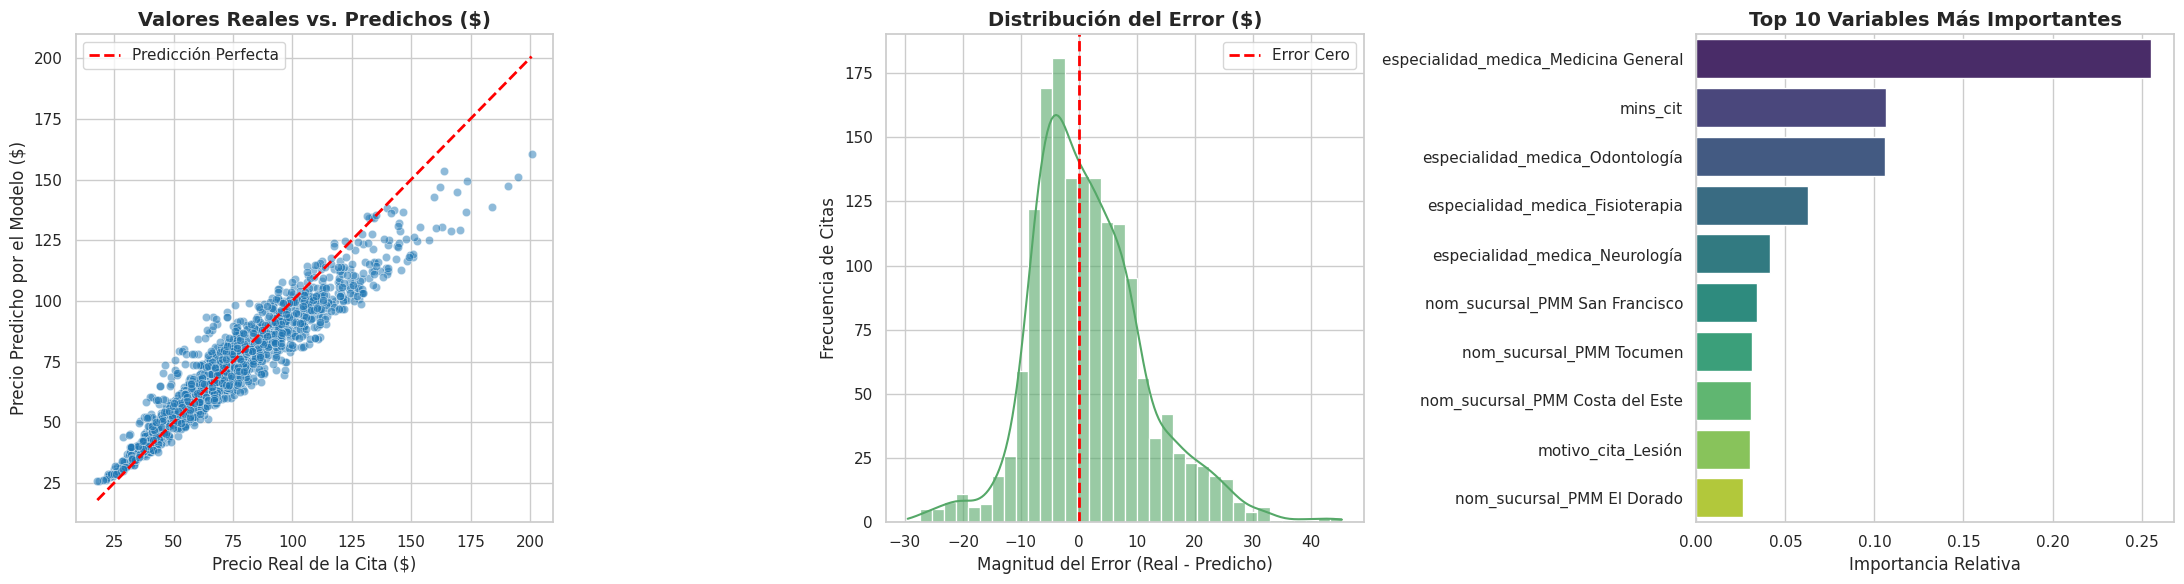

In [0]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

print("\n--- 5. Generación de Gráficas de Validación y Diagnóstico ---")

# Configuración de estilo
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# ---------------------------------------------------------
# GRÁFICA 1: Valores Reales vs. Predichos (Ejes Cruzados en Dólares)
# ---------------------------------------------------------
# Usamos las variables en dólares reales (y_test_reales y predicciones_reales)
sns.scatterplot(x=y_test_reales, y=predicciones_reales, alpha=0.5, ax=axes[0], color='#1f77b4')

# Línea de referencia ideal (Predicción perfecta de 45 grados)
limite_max = max(y_test_reales.max(), predicciones_reales.max())
limite_min = min(y_test_reales.min(), predicciones_reales.min())
axes[0].plot([limite_min, limite_max], [limite_min, limite_max], color='red', linestyle='--', linewidth=2, label='Predicción Perfecta')

axes[0].set_title("Valores Reales vs. Predichos ($)", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Precio Real de la Cita ($)", fontsize=12)
axes[0].set_ylabel("Precio Predicho por el Modelo ($)", fontsize=12)
axes[0].legend(loc="upper left")

# ---------------------------------------------------------
# GRÁFICA 2: Distribución del Error Real (Histograma de Residuos)
# ---------------------------------------------------------
# Calculamos el error en dólares
residuos_reales = y_test_reales - predicciones_reales

# Un histograma con curva KDE explica mucho mejor la magnitud del error para negocio
sns.histplot(residuos_reales, kde=True, ax=axes[1], color='g', alpha=0.6)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Error Cero')

axes[1].set_title("Distribución del Error ($)", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Magnitud del Error (Real - Predicho)", fontsize=12)
axes[1].set_ylabel("Frecuencia de Citas", fontsize=12)
axes[1].legend(loc="upper right")

# ---------------------------------------------------------
# GRÁFICA 3: Importancia de las Variables (Feature Importance)
# ---------------------------------------------------------
cat_encoder = pipeline.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
encoded_cat_cols = list(cat_encoder.get_feature_names_out(cols_categoricas))
todas_las_columnas = cols_numericas + encoded_cat_cols
importancias = pipeline.named_steps['model'].feature_importances_

df_importancia = pd.DataFrame({'Variable': todas_las_columnas, 'Importancia': importancias})
df_importancia = df_importancia.sort_values(by='Importancia', ascending=False).head(10)

sns.barplot(x='Importancia', y='Variable', data=df_importancia, ax=axes[2], hue='Variable', palette='viridis', legend=False)
axes[2].set_title("Top 10 Variables Más Importantes", fontsize=14, fontweight='bold')
axes[2].set_xlabel("Importancia Relativa", fontsize=12)
axes[2].set_ylabel("", fontsize=12)

plt.tight_layout()
plt.show()



--- 5. Generación de Gráficas de Validación Estructurales ---


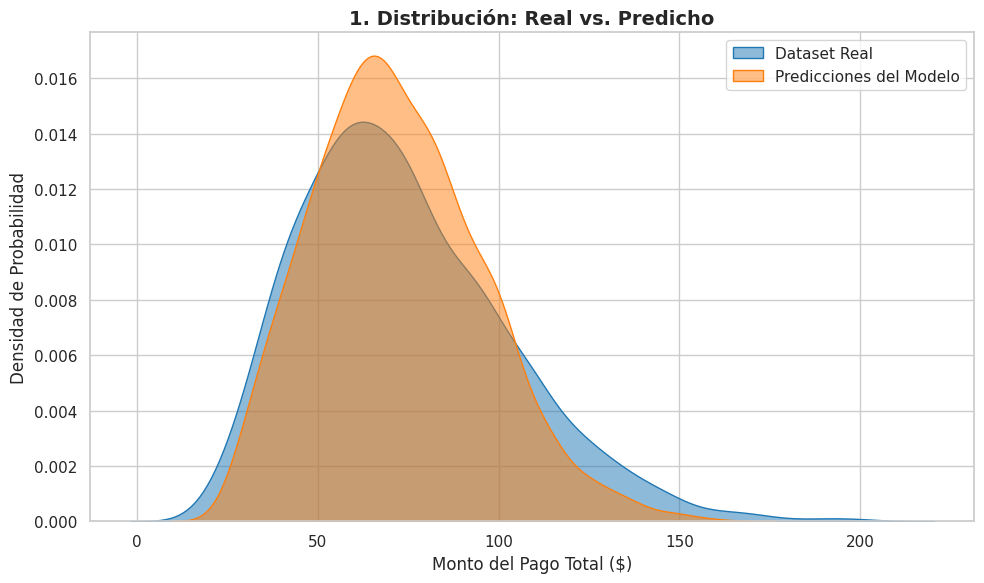

In [0]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

print("\n--- 5. Generación de Gráficas de Validación Estructurales ---")

# Configuración de estilo y dimensiones
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))


# Preparar DataFrame consolidado para facilitar la graficación de Seaborn
df_eval = pd.DataFrame({
    'Precio_Real': y_test_reales.values, 
    'Precio_Predicho': predicciones_reales
})

# ---------------------------------------------------------
# GRÁFICA 1: Comparativa de Distribuciones (KDE Plot)
# ---------------------------------------------------------
# Esta gráfica te permite ver si el modelo está sub-prediciendo o sobre-prediciendo volumen
sns.kdeplot(data=df_eval, x='Precio_Real', label='Dataset Real', fill=True, color='#1f77b4', alpha=0.5)
sns.kdeplot(data=df_eval, x='Precio_Predicho', label='Predicciones del Modelo', fill=True, color='#ff7f0e', alpha=0.5)

plt.title("1. Distribución: Real vs. Predicho", fontsize=14, fontweight='bold')
plt.xlabel("Monto del Pago Total ($)", fontsize=12)
plt.ylabel("Densidad de Probabilidad", fontsize=12)
plt.legend()

plt.tight_layout()
plt.show()

In [0]:
import pandas as pd
import numpy as np

print("--- 1. Tabla de Predicciones vs. Valores Reales (Auditoría) ---")


# 1.1 Reconstrucción del conjunto de prueba
# Se copia X_test para no alterar las variables originales utilizadas por el modelo calculado justo arriba
df_auditoria = X_test.copy()

# 1.2 Integración de resultados
df_auditoria['Precio Real ($)'] = y_test_reales.values.round(2)
df_auditoria['Precio Predicho ($)'] = predicciones_reales.astype(np.float64).round(2) # Se casteó a flotanto de 64 bits por culpa de un problema con los flotantes enviados por el modelo XGBoost

# 1.3 Cálculo del residuo y error absoluto
# Esto facilita aislar los casos donde el modelo memorizó perfectamente vs. donde falló.
df_auditoria['Residuo ($)'] = df_auditoria['Precio Real ($)'] - df_auditoria['Precio Predicho ($)']
df_auditoria['Residuo ($)'] = df_auditoria['Residuo ($)'].round(2)
df_auditoria['Error Absoluto ($)'] = np.abs(df_auditoria['Residuo ($)']).round(2)

# 1.4 Ordenamiento estratégico
# Ordenamos de mayor a menor error para inspeccionar inmediatamente los peores escenarios.
df_auditoria = df_auditoria.sort_values(by='Residuo ($)', ascending=True)
display(df_auditoria)

print("\n--- 2. Tabla Resumen de Métricas de Evaluación ---")

# 2.1 Construcción del diccionario de resultados
tabla_metricas = {
    'Métrica': [
        'Mean Absolute Error (MAE)', 
        'Root Mean Squared Error (RMSE)', 
        'R-Squared (R2)'
    ],
    'Valor': [
        f"${mae:.2f}", 
        f"${rmse:.2f}", 
        f"{r2:.2f}"
    ],
    'Impacto en Negocio / Diagnóstico': [
        'Desviación promedio de la predicción respecto a la tarifa real.',
        'Penalización de errores atípicos (outliers) en las predicciones de precios.',
        'Proporción de varianza explicada (en este caso el 88% de los datos son explicados por el modelo).'
    ]
}

# 2.2 Conversión y visualización

df_metricas = pd.DataFrame(tabla_metricas)
display(df_metricas)

--- 1. Tabla de Predicciones vs. Valores Reales (Auditoría) ---


mins_cit,motivo_cita,sexo_pac,fechaNac_pac,edad_pac_cita,peso_kg,altura_m,imc,especialidad_medica,nom_sucursal,mes,dia_semana,Precio Real ($),Precio Predicho ($),Residuo ($),Error Absoluto ($)
60,Control de Crecimiento,M,2020-03-29,5,8.7,0.7,17.8,Pediatría,PMM Costa del Este,7,6,63.68,93.2,-29.52,29.52
60,Control de Crecimiento,M,2017-02-18,8,18.2,1.07,15.9,Pediatría,PMM Brisas del Golf,9,6,46.54,73.72,-27.18,27.18
60,Control de Crecimiento,F,2018-09-14,7,9.8,0.82,14.6,Pediatría,PMM El Dorado,9,3,52.29,79.37,-27.08,27.08
60,Control Anual,F,1974-11-13,50,54.8,1.62,20.9,Ginecología,PMM San Francisco,9,6,66.58,93.25,-26.67,26.67
60,Control de Crecimiento,F,2010-06-08,14,29.7,1.3,17.6,Pediatría,PMM El Dorado,3,6,53.44,79.37,-25.93,25.93
45,Control de Crecimiento,F,2016-09-01,8,14.8,1.02,14.2,Pediatría,PMM San Francisco,5,4,54.36,80.2,-25.84,25.84
30,Control de Crecimiento,F,2018-10-03,6,12.0,0.84,17.0,Pediatría,PMM Costa del Este,2,2,50.7,75.74,-25.04,25.04
30,Control de Crecimiento,F,2015-03-14,10,24.9,1.12,19.9,Pediatría,PMM San Francisco,6,3,45.42,70.41,-24.99,24.99
60,Control Anual,F,1993-02-28,32,74.0,1.65,27.2,Ginecología,PMM San Francisco,8,4,67.91,92.67,-24.76,24.76
45,Control Anual,F,1977-11-29,47,54.7,1.5,24.3,Ginecología,PMM San Francisco,5,7,60.38,84.4,-24.02,24.02



--- 2. Tabla Resumen de Métricas de Evaluación ---


Métrica,Valor,Impacto en Negocio / Diagnóstico
Mean Absolute Error (MAE),$7.55,Desviación promedio de la predicción respecto a la tarifa real.
Root Mean Squared Error (RMSE),$10.07,Penalización de errores atípicos (outliers) en las predicciones de precios.
R-Squared (R2),0.88,Proporción de varianza explicada (en este caso el 88% de los datos son explicados por el modelo).
